<a href="https://colab.research.google.com/github/Daprosero/Domain_Adaptation/blob/main/CREDA/Notebooks/Plots_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
from importlib import metadata as importlib_metadata
import os
import re
import subprocess
import sys
import tempfile
import zipfile
from pathlib import Path

MIGRATED_PROJECT_MARKER = ("src", "CREDA")
DEFAULT_DOMAIN_ADAPTATION_REPOSITORY = 'https://github.com/Daprosero/Domain_Adaptation.git'
DOMAIN_ADAPTATION_REPOSITORY = os.environ.get('DOMAIN_ADAPTATION_REPOSITORY', DEFAULT_DOMAIN_ADAPTATION_REPOSITORY)
OFFICECALTECH_REPOSITORY = "https://github.com/ZhangJUJU/OfficeCaltechDomainAdaptation.git"
IMAGECLEF_FILE_ID = "1G0x-arLRPuE-IKDfkxSa-bvPMltvYVsf"


def run_command(*command):
    return subprocess.run(command, check=True)


def detect_runtime():
    if "COLAB_RELEASE_TAG" in os.environ:
        return "Colab"
    if "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
        return "Kaggle"
    return "local"


def ensure_umap_learn():
    try:
        pass  # umap-learn is installed later from requirements.txt
    except ImportError:
        pass


RUNTIME = detect_runtime()
# The canonical requirements installation below provides the CPU UMAP fallback.
print(f"Runtime: {RUNTIME}. cuML is used when the CUDA/RAPIDS environment provides it; otherwise umap-learn is used.")


MANAGED_CLOUD_REQUIREMENTS = {"torch", "torchvision", "jupyter", "ipykernel"}
BINARY_EXTENSION_SUFFIXES = (".so", ".pyd", ".dll", ".dylib")


def requirement_name(requirement_line):
    requirement = requirement_line.split("#", 1)[0].split(";", 1)[0].strip()
    match = re.match(r"[A-Za-z0-9_.-]+", requirement)
    return match.group(0).lower().replace("_", "-") if match else None


def write_cloud_requirements(requirements_path, destination):
    cloud_requirements = [
        line for line in requirements_path.read_text(encoding="utf-8").splitlines(keepends=True)
        if requirement_name(line) not in MANAGED_CLOUD_REQUIREMENTS
    ]
    destination.write_text("".join(cloud_requirements), encoding="utf-8")


def binary_packages_from_report(report_path):
    report = json.loads(report_path.read_text(encoding="utf-8"))
    changed_binary_packages = []
    for installation in report.get("install", []):
        package_name = installation.get("metadata", {}).get("name")
        if not package_name:
            continue
        try:
            installed_files = importlib_metadata.distribution(package_name).files
        except importlib_metadata.PackageNotFoundError:
            changed_binary_packages.append(package_name)
            continue
        if installed_files is None or any(
            str(path).lower().endswith(BINARY_EXTENSION_SUFFIXES) for path in installed_files
        ):
            changed_binary_packages.append(package_name)
    return changed_binary_packages


def request_cloud_restart(changed_binary_packages):
    package_list = ", ".join(changed_binary_packages)
    if RUNTIME == "Kaggle":
        raise RuntimeError(
            f"Kaggle installed binary package(s): {package_list}. Restart the session and rerun this notebook before scientific imports."
        )

    print(f"Colab installed binary package(s): {package_list}. Requesting a runtime restart before scientific imports.")
    try:
        from google.colab import runtime as colab_runtime
        restart = getattr(colab_runtime, "restart", None)
        if callable(restart):
            restart()
        else:
            from IPython import get_ipython
            shell = get_ipython()
            if shell is not None and getattr(shell, "kernel", None) is not None:
                shell.kernel.do_shutdown(restart=True)
    except (ImportError, AttributeError):
        pass
    raise RuntimeError(
        "Colab dependencies changed. Restart the runtime if it did not restart automatically, then rerun this notebook."
    )


def install_project_requirements(requirements_path):
    if RUNTIME == "local":
        run_command(sys.executable, "-m", "pip", "install", "-r", str(requirements_path))
        return

    with tempfile.TemporaryDirectory(prefix="domain-adaptation-pip-") as temporary_directory:
        temporary_directory = Path(temporary_directory)
        cloud_requirements_path = temporary_directory / "requirements-cloud.txt"
        report_path = temporary_directory / "pip-install-report.json"
        write_cloud_requirements(requirements_path, cloud_requirements_path)
        run_command(
            sys.executable, "-m", "pip", "install", "--report", str(report_path),
            "-r", str(cloud_requirements_path),
        )
        if not report_path.is_file():
            raise RuntimeError("pip did not produce an installation report; restart before scientific imports.")
        changed_binary_packages = binary_packages_from_report(report_path)
        if changed_binary_packages:
            request_cloud_restart(changed_binary_packages)


def is_repository_root(candidate):
    return candidate.joinpath(*MIGRATED_PROJECT_MARKER).is_dir() and (candidate / 'pyproject.toml').is_file()


def cloud_repository_destination():
    if 'COLAB_RELEASE_TAG' in os.environ:
        return Path('/content/Domain_Adaptation')
    if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
        return Path('/kaggle/working/Domain_Adaptation')
    return None


def find_repository_root():
    candidates = [Path(os.environ["DOMAIN_ADAPTATION_ROOT"])] if "DOMAIN_ADAPTATION_ROOT" in os.environ else []
    candidates.extend([Path.cwd(), *Path.cwd().parents, Path("/content/Domain_Adaptation"), Path("/kaggle/working/Domain_Adaptation"), Path("/kaggle/input/domain-adaptation")])
    for candidate in candidates:
        if (candidate / "src" / "CREDA").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate.resolve()

    destination = cloud_repository_destination()
    if destination is not None:
        if not destination.exists():
            run_command('git', 'clone', DOMAIN_ADAPTATION_REPOSITORY, str(destination))
        if is_repository_root(destination):
            return destination.resolve()
        raise FileNotFoundError(f'Cloud repository destination is not a valid CREDA checkout: {destination}')

    cache_root = Path(os.environ.get("DOMAIN_ADAPTATION_CACHE", Path.cwd() / ".domain-adaptation-cache")).expanduser()
    raise FileNotFoundError(
        "A local migrated Domain_Adaptation checkout containing src/CREDA is required. "
        "Set DOMAIN_ADAPTATION_ROOT to that checkout."
    )


REPOSITORY_ROOT = find_repository_root()
CACHE_ROOT = Path(os.environ.get(
    "DOMAIN_ADAPTATION_CACHE",
    REPOSITORY_ROOT.parent if REPOSITORY_ROOT.parent.name == ".domain-adaptation-cache" else REPOSITORY_ROOT / ".domain-adaptation-cache",
)).expanduser().resolve()
DIGITS_ROOT = CACHE_ROOT / "digits"
DIGITS_ROOT.mkdir(parents=True, exist_ok=True)
OFFICECALTECH_ROOT = CACHE_ROOT / "OfficeCaltechDomainAdaptation" / "images"
IMAGECLEF_ROOT = CACHE_ROOT / "ImageCLEF-DA" / "image_CLEF"

if not (CACHE_ROOT / "OfficeCaltechDomainAdaptation").exists():
    CACHE_ROOT.mkdir(parents=True, exist_ok=True)
    run_command("git", "clone", OFFICECALTECH_REPOSITORY, str(CACHE_ROOT / "OfficeCaltechDomainAdaptation"))

requirements_path = REPOSITORY_ROOT / "requirements.txt"
if not requirements_path.is_file():
    raise FileNotFoundError(f"Canonical requirements file is missing: {requirements_path}")
install_project_requirements(requirements_path)
imageclef_zip = CACHE_ROOT / "ImageCLEF-DA.zip"
if not imageclef_zip.is_file():
    run_command("gdown", "--id", IMAGECLEF_FILE_ID, "--output", str(imageclef_zip))
if not IMAGECLEF_ROOT.is_dir():
    with zipfile.ZipFile(imageclef_zip) as archive:
        archive.extractall(CACHE_ROOT / "ImageCLEF-DA")

os.environ.setdefault("DOMAIN_ADAPTATION_ROOT", str(REPOSITORY_ROOT))
os.environ.setdefault("DOMAIN_ADAPTATION_CACHE", str(CACHE_ROOT))
os.environ.setdefault("DOMAIN_ADAPTATION_IMAGECLEF_ROOT", str(IMAGECLEF_ROOT))
os.environ.setdefault("DOMAIN_ADAPTATION_OFFICECALTECH_ROOT", str(OFFICECALTECH_ROOT))
sys.path.insert(0, str(REPOSITORY_ROOT / "src"))

from CREDA.artifacts import resolve_artifact_paths, resolve_imageclef_root, resolve_officecaltech_root
ARTIFACT_PATHS = resolve_artifact_paths(REPOSITORY_ROOT)
PAPER_RESULTS_DIR = ARTIFACT_PATHS["results"] / "Paper_Results"
PAPER_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
IMAGECLEF_ROOT = resolve_imageclef_root(REPOSITORY_ROOT)
OFFICECALTECH_ROOT = resolve_officecaltech_root(REPOSITORY_ROOT)


Runtime: Colab. cuML is used when the CUDA/RAPIDS environment provides it; otherwise umap-learn is used.


In [2]:
# torchcam is installed from the canonical requirements.txt during bootstrap.


In [3]:
import os
import zipfile
import matplotlib.patches as patches
import matplotlib as mpl
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split, ConcatDataset

from torchvision import models, datasets, transforms
from torchvision.datasets import ImageFolder
from torchvision.models import (
    resnet18, resnet34, resnet50,
    ResNet18_Weights, ResNet34_Weights, ResNet50_Weights
)
from torchvision.transforms.functional import to_pil_image
import random
import numpy as np
import timm
from sklearn.preprocessing import MinMaxScaler
try:
    from cuml.manifold.umap import UMAP as UMAP
    UMAP_BACKEND = "cuML/CUDA"
except ImportError:
    from umap import UMAP
    UMAP_BACKEND = "umap-learn/CPU"


def fit_umap_2d(features):
    reducer = UMAP(n_components=2, n_neighbors=80, random_state=42)
    return np.asarray(reducer.fit_transform(features))


print(f"Active UMAP backend: {UMAP_BACKEND}")
from torchcam.methods import GradCAMpp
from torchcam.utils import overlay_mask
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader
from CREDA.models import (
    FeatureExtractor,
    Classifier,
    DomainDiscriminator,
    DANN_ResNet,
    ADDA_ResNet,
    CDAN_ResNet,
    CREDA_ResNet,
    GradientReversalFunction,
    GradientReversalLayer,
    CREDALoss
)
torch.serialization.add_safe_globals([
    FeatureExtractor,
    Classifier,
    DomainDiscriminator,
    DANN_ResNet,
    ADDA_ResNet,
    CDAN_ResNet,
    CREDA_ResNet,
    GradientReversalFunction,
    GradientReversalLayer
])

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

Active UMAP backend: umap-learn/CPU


In [4]:
from CREDA.training_pipeline import (extract_features_adaptive,
                                                              load_model,
                                                              resolve_device,
                                                              extract_features_model,
                                                              extract_features_baseline,
                                                              extract_flattened_features,
                                                              split_stratified,
                                                              resize_image_pil,
                                                              tensor_to_imgarray,
                                                              pil_to_imgarray,
                                                              get_one_sample_per_selected_classes,
                                                              get_representative_per_class,
                                                              show_digit_domains_grid,
                                                              show_multi_domain_class_grid,
                                                              get_last_conv_layer,
                                                              get_denormalizer,
                                                              norm_cam,
                                                              get_nth_image_for_class)


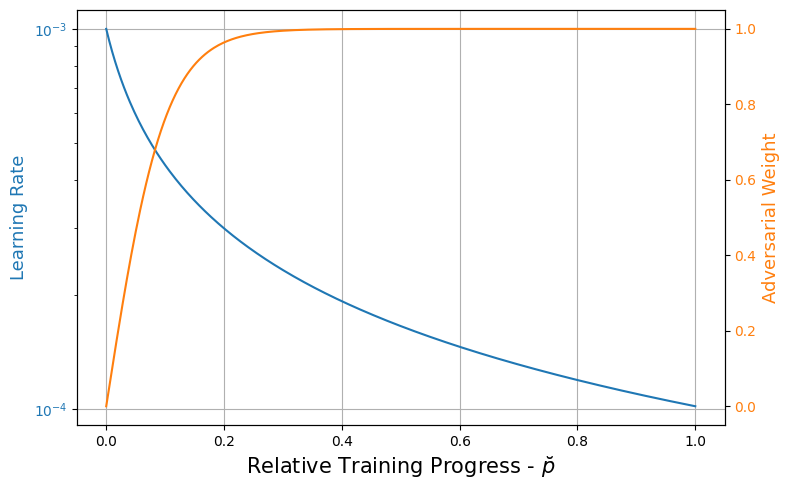

In [5]:
# Parámetros
alpha = 20
beta = 0.75
delta = 20
eta_0 = 1e-3
n = 20

# Rango de p
epochs = np.linspace(0, n, 20 * n)
p = epochs / n

# Ecuaciones
eta = eta_0 * (1 + alpha * p) ** (-beta)
lambda_ = (1 - np.exp(-delta * p)) / (1 + np.exp(-delta * p))

# Figura y doble eje y
fig, ax1 = plt.subplots(figsize=(8, 5))

# Eje y izquierdo (eta)
color_eta = "tab:blue"
ax1.set_xlabel(r'Relative Training Progress - $\breve{p}$', fontsize=15)
ax1.set_ylabel(r'Learning Rate', color=color_eta, fontsize=13)
ln1 = ax1.plot(p, eta, color=color_eta, label=r'$\eta(\breve{p}) = \eta_0 (1 + \alpha \breve{p})^{-\beta}$')
ax1.tick_params(axis='y', labelcolor=color_eta)
ax1.set_yscale('log')

# Eje y derecho (lambda)
ax2 = ax1.twinx()
color_lambda = "tab:orange"
ax2.set_ylabel('Adversarial Weight', color=color_lambda, fontsize=13)
ln2 = ax2.plot(p, lambda_, color=color_lambda, label=r'$\lambda(\breve{p}) = \frac{1 - e^{-\delta \breve{p}}}{1 + e^{-\delta \breve{p}}}$')
ax2.tick_params(axis='y', labelcolor=color_lambda)

# Unir leyendas de ambos ejes
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
#ax1.legend(lns, labs, loc="best")

# Estilo
ax1.grid(True)
fig.tight_layout()

# Guardar y mostrar
plt.savefig(PAPER_RESULTS_DIR / "eta_lambda_plot.pdf", format="pdf")
plt.show()

In [6]:
if not IMAGECLEF_ROOT.is_dir():
    with zipfile.ZipFile(imageclef_zip, "r") as archive:
        archive.extractall(IMAGECLEF_ROOT.parent)

# Verificar contenido
os.listdir(IMAGECLEF_ROOT)


['list', 'b', 'i', 'c', 'p']

In [7]:
set_seed(42)
# Transforms
transform_digits = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

transform_clef = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset loading
mnist_full = datasets.MNIST(root=DIGITS_ROOT, train=True, download=True, transform=transform_digits)
usps_full = datasets.USPS(root=DIGITS_ROOT, train=True, download=True, transform=transform_digits)
svhn_full = datasets.SVHN(root=DIGITS_ROOT, split='train', download=True, transform=transform_digits)

I_full = ImageFolder(IMAGECLEF_ROOT / "i", transform=transform_clef)
P_full = ImageFolder(IMAGECLEF_ROOT / "p", transform=transform_clef)
C_full = ImageFolder(IMAGECLEF_ROOT / "c", transform=transform_clef)

A_full = ImageFolder(OFFICECALTECH_ROOT / "amazon", transform=transform_clef)
W_full = ImageFolder(OFFICECALTECH_ROOT / "webcam", transform=transform_clef)
D_full = ImageFolder(OFFICECALTECH_ROOT / "dslr", transform=transform_clef)

# Agrupación
set_1 = {"M": mnist_full, "U": usps_full, "S": svhn_full}
set_2 = {"I": I_full, "P": P_full, "C": C_full}
set_3 = {"A": A_full, "W": W_full, "D": D_full}
sets_all = {
    "MNIST-USPS-SVHN": set_1,
    "ImageCLEF": set_2,
    "Office-Caltech": set_3
}
combinations_dict = {
    "MNIST-USPS-SVHN": ("M", "U"),  # MNIST → USPS
    "ImageCLEF": ("I", "C"),        # Imagenet → Photo
    "Office-Caltech": ("W", "D")    # Webcam → DSLR
}

100%|██████████| 9.91M/9.91M [00:00<00:00, 56.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.79MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.59MB/s]
100%|██████████| 6.58M/6.58M [00:01<00:00, 3.37MB/s]
100%|██████████| 182M/182M [00:14<00:00, 12.3MB/s]


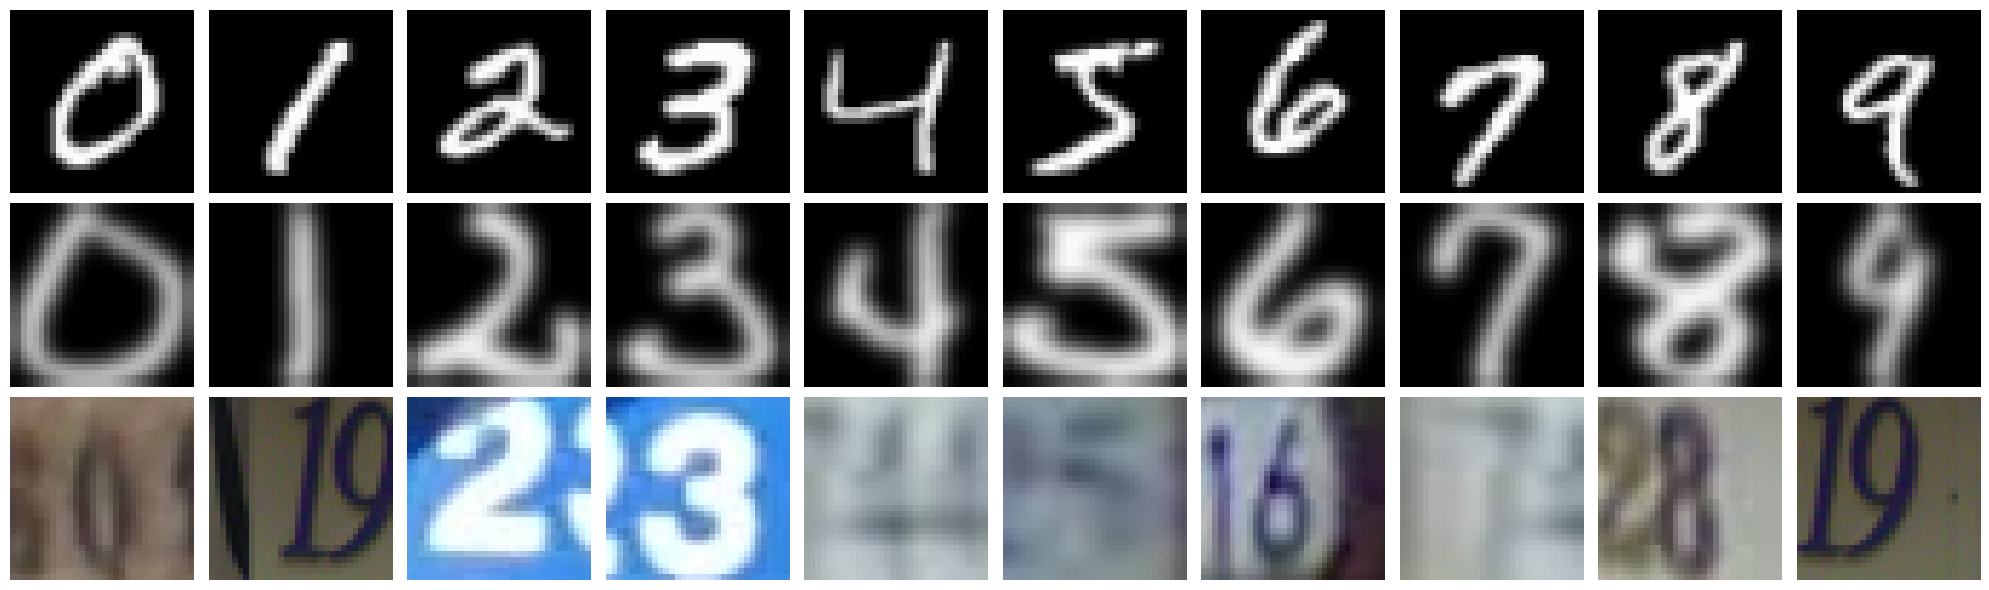

In [8]:
device = resolve_device()
selected_classes = list(range(10))
domains = ["M", "U", "S"]

# Cargar datasets sin transformaciones
mnist_raw = datasets.MNIST(root=DIGITS_ROOT, train=True, download=True)
usps_raw = datasets.USPS(root=DIGITS_ROOT, train=True, download=True)
svhn_raw = datasets.SVHN(root=DIGITS_ROOT, split='train', download=True)

datasets_digits = [mnist_raw, usps_raw, svhn_raw]
show_digit_domains_grid(domains, datasets_digits, selected_classes, output_dir=PAPER_RESULTS_DIR)

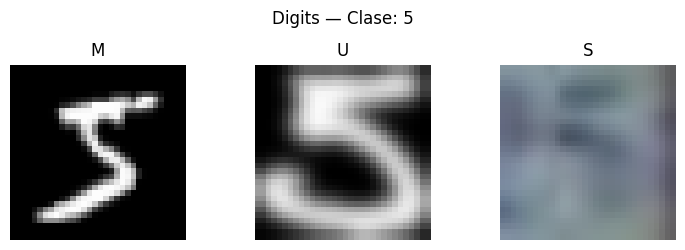

In [9]:
show_digit_domains_grid(domains, datasets_digits, selected_classes,
                        title="Digits", only_class=5, output_dir=PAPER_RESULTS_DIR)

In [10]:
folder_name_to_class = {
    "1": "aeroplane",
    "2": "bike",
    "3": "bird",
    "4": "boat",
    "5": "bottle",
    "6": "bus",
    "7": "car",
    "8": "dog",
    "9": "horse",
    "10": "monitor",
    "11": "motorbike",
    "12": "people"
}

clef_paths = {
    "P": IMAGECLEF_ROOT / "p",
    "I": IMAGECLEF_ROOT / "i",
    "C": IMAGECLEF_ROOT / "c"
}

folder_name_to_class = {
    "0": "aeroplane",
    "1": "bike",
    "2": "bird",
    "3": "boat",
    "4": "bottle",
    "5": "bus",
    "6": "car",
    "7": "dog",
    "8": "horse",
    "9": "monitor",
    "10": "motorbike",
    "11": "people"
}

clef_datasets = {}
for k, v in clef_paths.items():
    ds = ImageFolder(v)
    # Orden real en que ImageFolder ve las carpetas (alfabéticamente)
    folder_order = ds.classes  # e.g., ['1', '10', '11', ..., '9']
    ds.classes = [folder_name_to_class[c] for c in folder_order]
    clef_datasets[k] = ds

# Visualización corregida
show_multi_domain_class_grid(clef_datasets, title="imageclef", output_dir=PAPER_RESULTS_DIR)

Output hidden; open in https://colab.research.google.com to view.

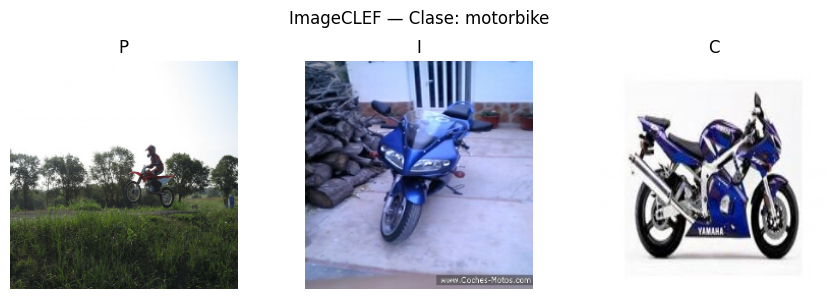

In [11]:
show_multi_domain_class_grid(clef_datasets, title="ImageCLEF", only_class=2, output_dir=PAPER_RESULTS_DIR)

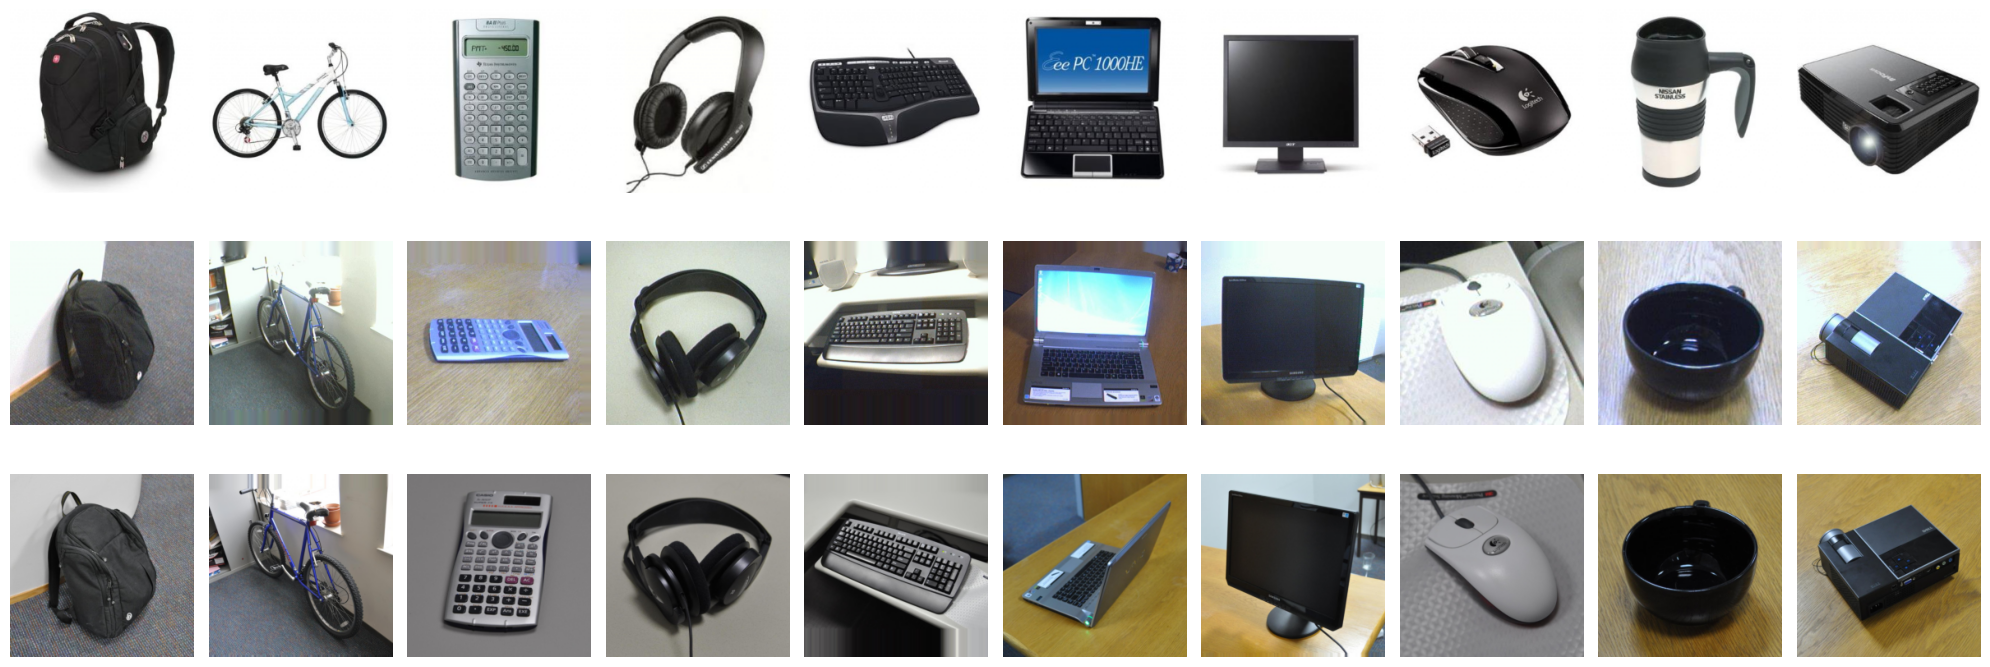

In [12]:
office_paths = {
    "A": OFFICECALTECH_ROOT / "amazon",
    "W": OFFICECALTECH_ROOT / "webcam",
    "D": OFFICECALTECH_ROOT / "dslr"
}

office_datasets = {k: ImageFolder(v) for k, v in office_paths.items()}
show_multi_domain_class_grid(office_datasets, title="office", output_dir=PAPER_RESULTS_DIR)


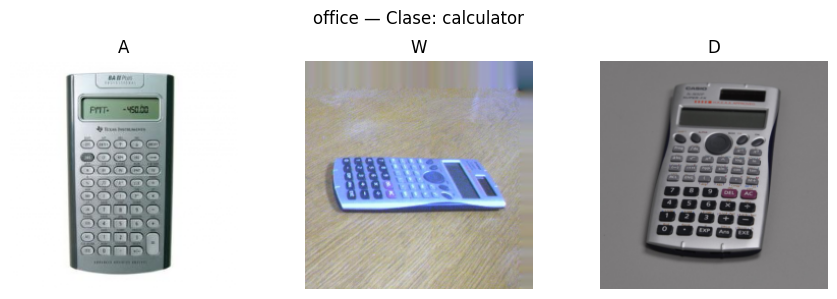

In [13]:
show_multi_domain_class_grid(office_datasets, title="office", only_class=2, output_dir=PAPER_RESULTS_DIR)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

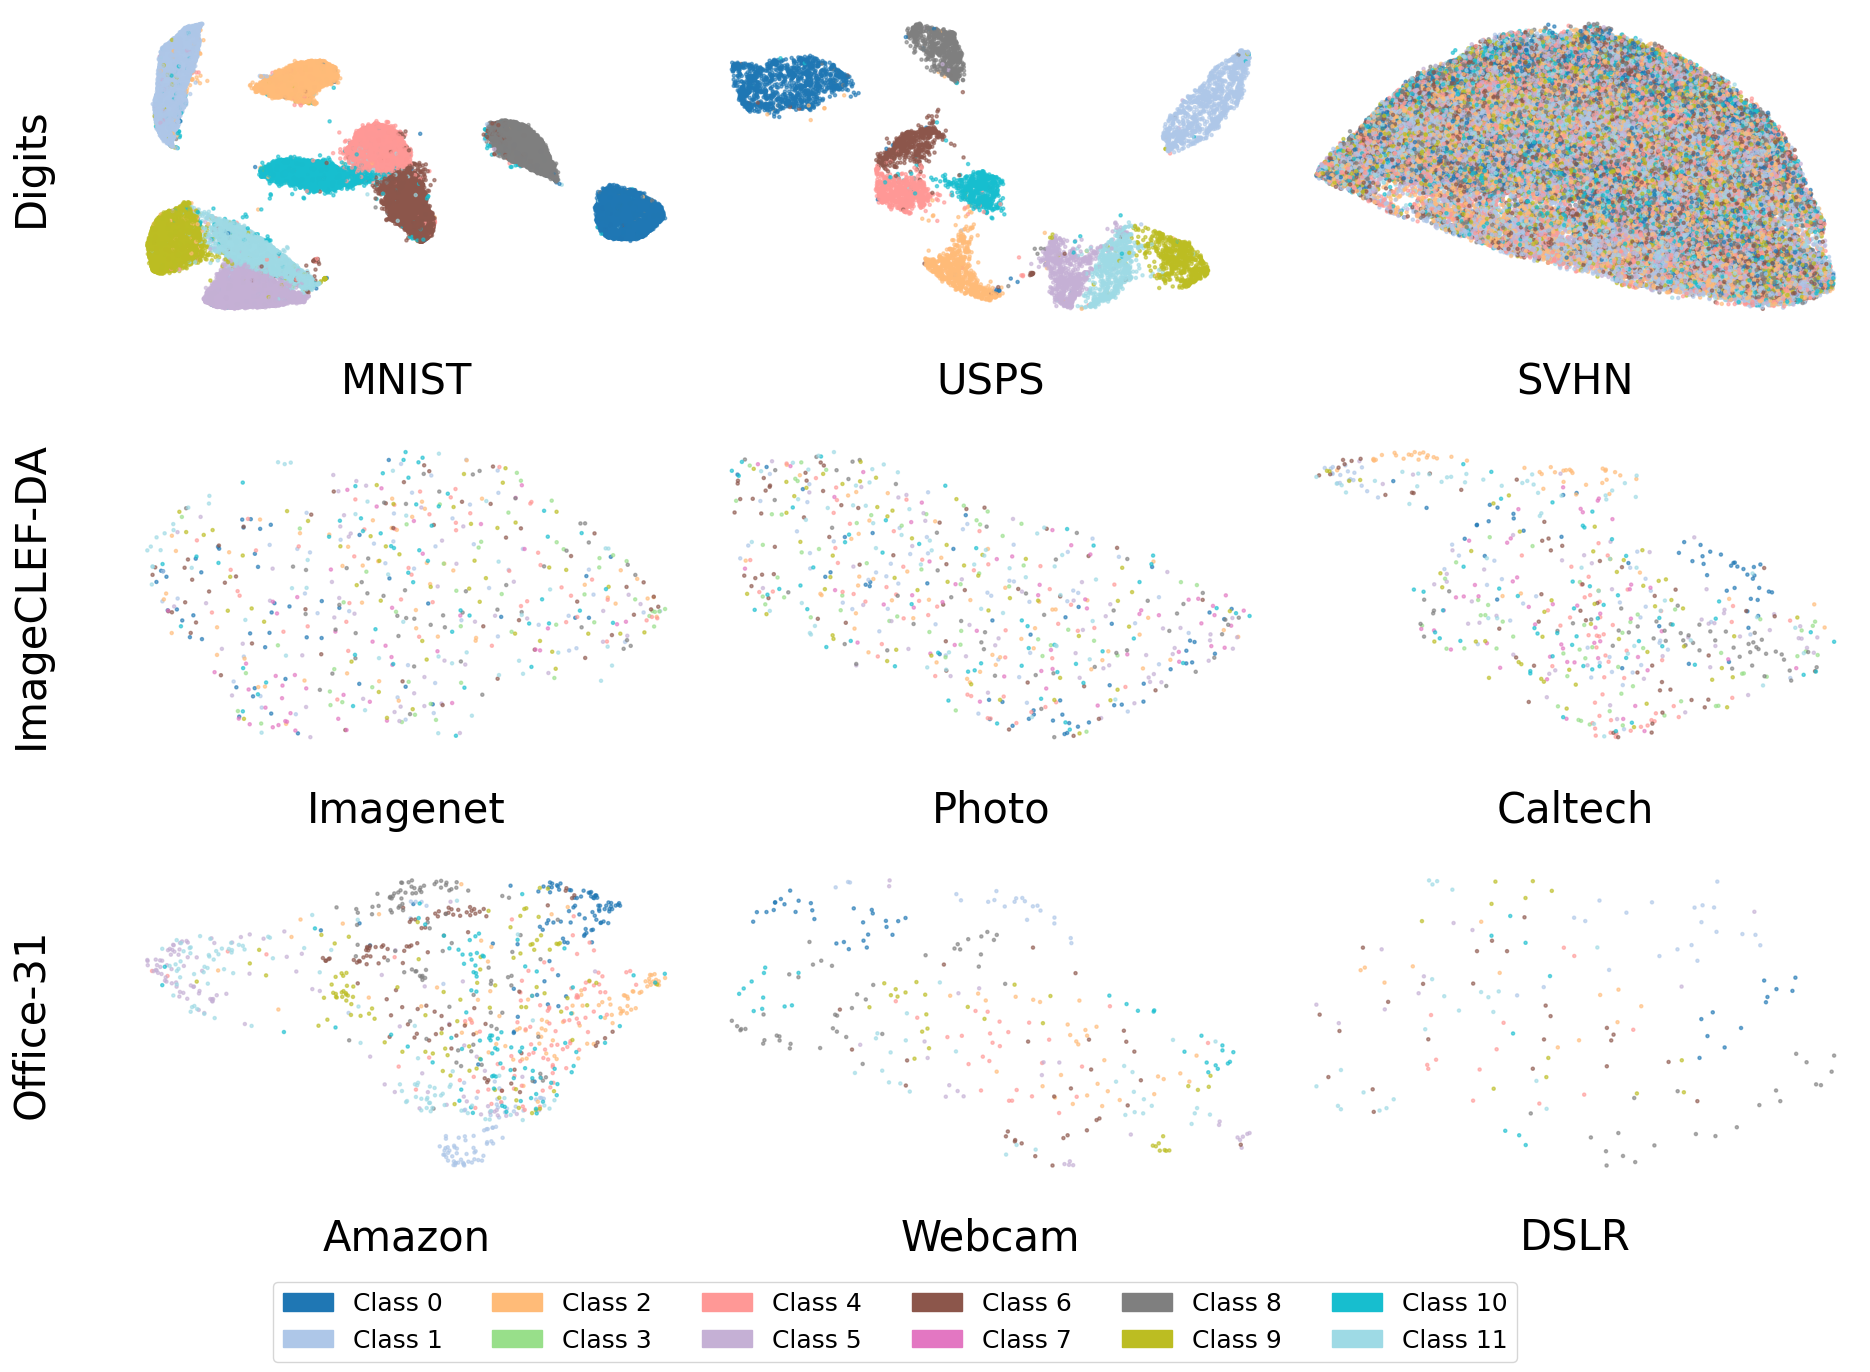

In [14]:
# Configuración
dataset_names = ["MNIST-USPS-SVHN", "ImageCLEF", "Office-Caltech"]
dataset_labels = [["MNIST", "USPS", "SVHN"],
                  ["Imagenet", "Photo", "Caltech"],
                  ["Amazon", "Webcam", "DSLR"]]

device = resolve_device()
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

# Paleta de colores para hasta 12 clases
colors = plt.colormaps.get_cmap('tab20').resampled(12)  # 12 discrete colors



# Loop sobre filas y columnas
for row_idx, dataset_key in enumerate(dataset_names):
    domain_dict = sets_all[dataset_key]
    domain_names = list(domain_dict.keys())

    for col_idx, domain_code in enumerate(domain_names):
        dataset = domain_dict[domain_code]
        ax = axes[row_idx, col_idx]

        try:
            X, y = extract_flattened_features(dataset)

            Z = fit_umap_2d(MinMaxScaler().fit_transform(X))

            scatter = ax.scatter(Z[:, 0], Z[:, 1], c=y, cmap=colors, s=5, alpha=0.6)
            ax.axis("off")

            # Etiqueta de columna
            ax.text(0.5, -0.12, dataset_labels[row_idx][col_idx],
                transform=ax.transAxes,
                ha='center', va='top',
                fontsize=30)



        except Exception as e:
            ax.set_title(f"{domain_code} Failed", fontsize=10, color="red")
            ax.axis("off")
            print(f"[Error] {domain_code}: {e}")

# Etiquetas laterales (filas)
row_labels = ["Digits", "ImageCLEF-DA", "Office-31"]
for ax, row_label in zip(axes[:, 0], row_labels):
    ax.annotate(row_label, xy=(0, 0.5), xytext=(-50, 0),
                xycoords='axes fraction', textcoords='offset points',
                size=30, ha='right', va='center', rotation=90)

# Leyenda manual
handles = [mpl.patches.Patch(color=colors(i), label=f'Class {i}') for i in range(12)]
fig.legend(handles, [f'Class {i}' for i in range(12)],
           loc='lower center', ncol=6, fontsize=18, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0.05, 0.05, 0.99, 0.70])
plt.savefig(PAPER_RESULTS_DIR / "umap_original.pdf", format="pdf", bbox_inches="tight")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

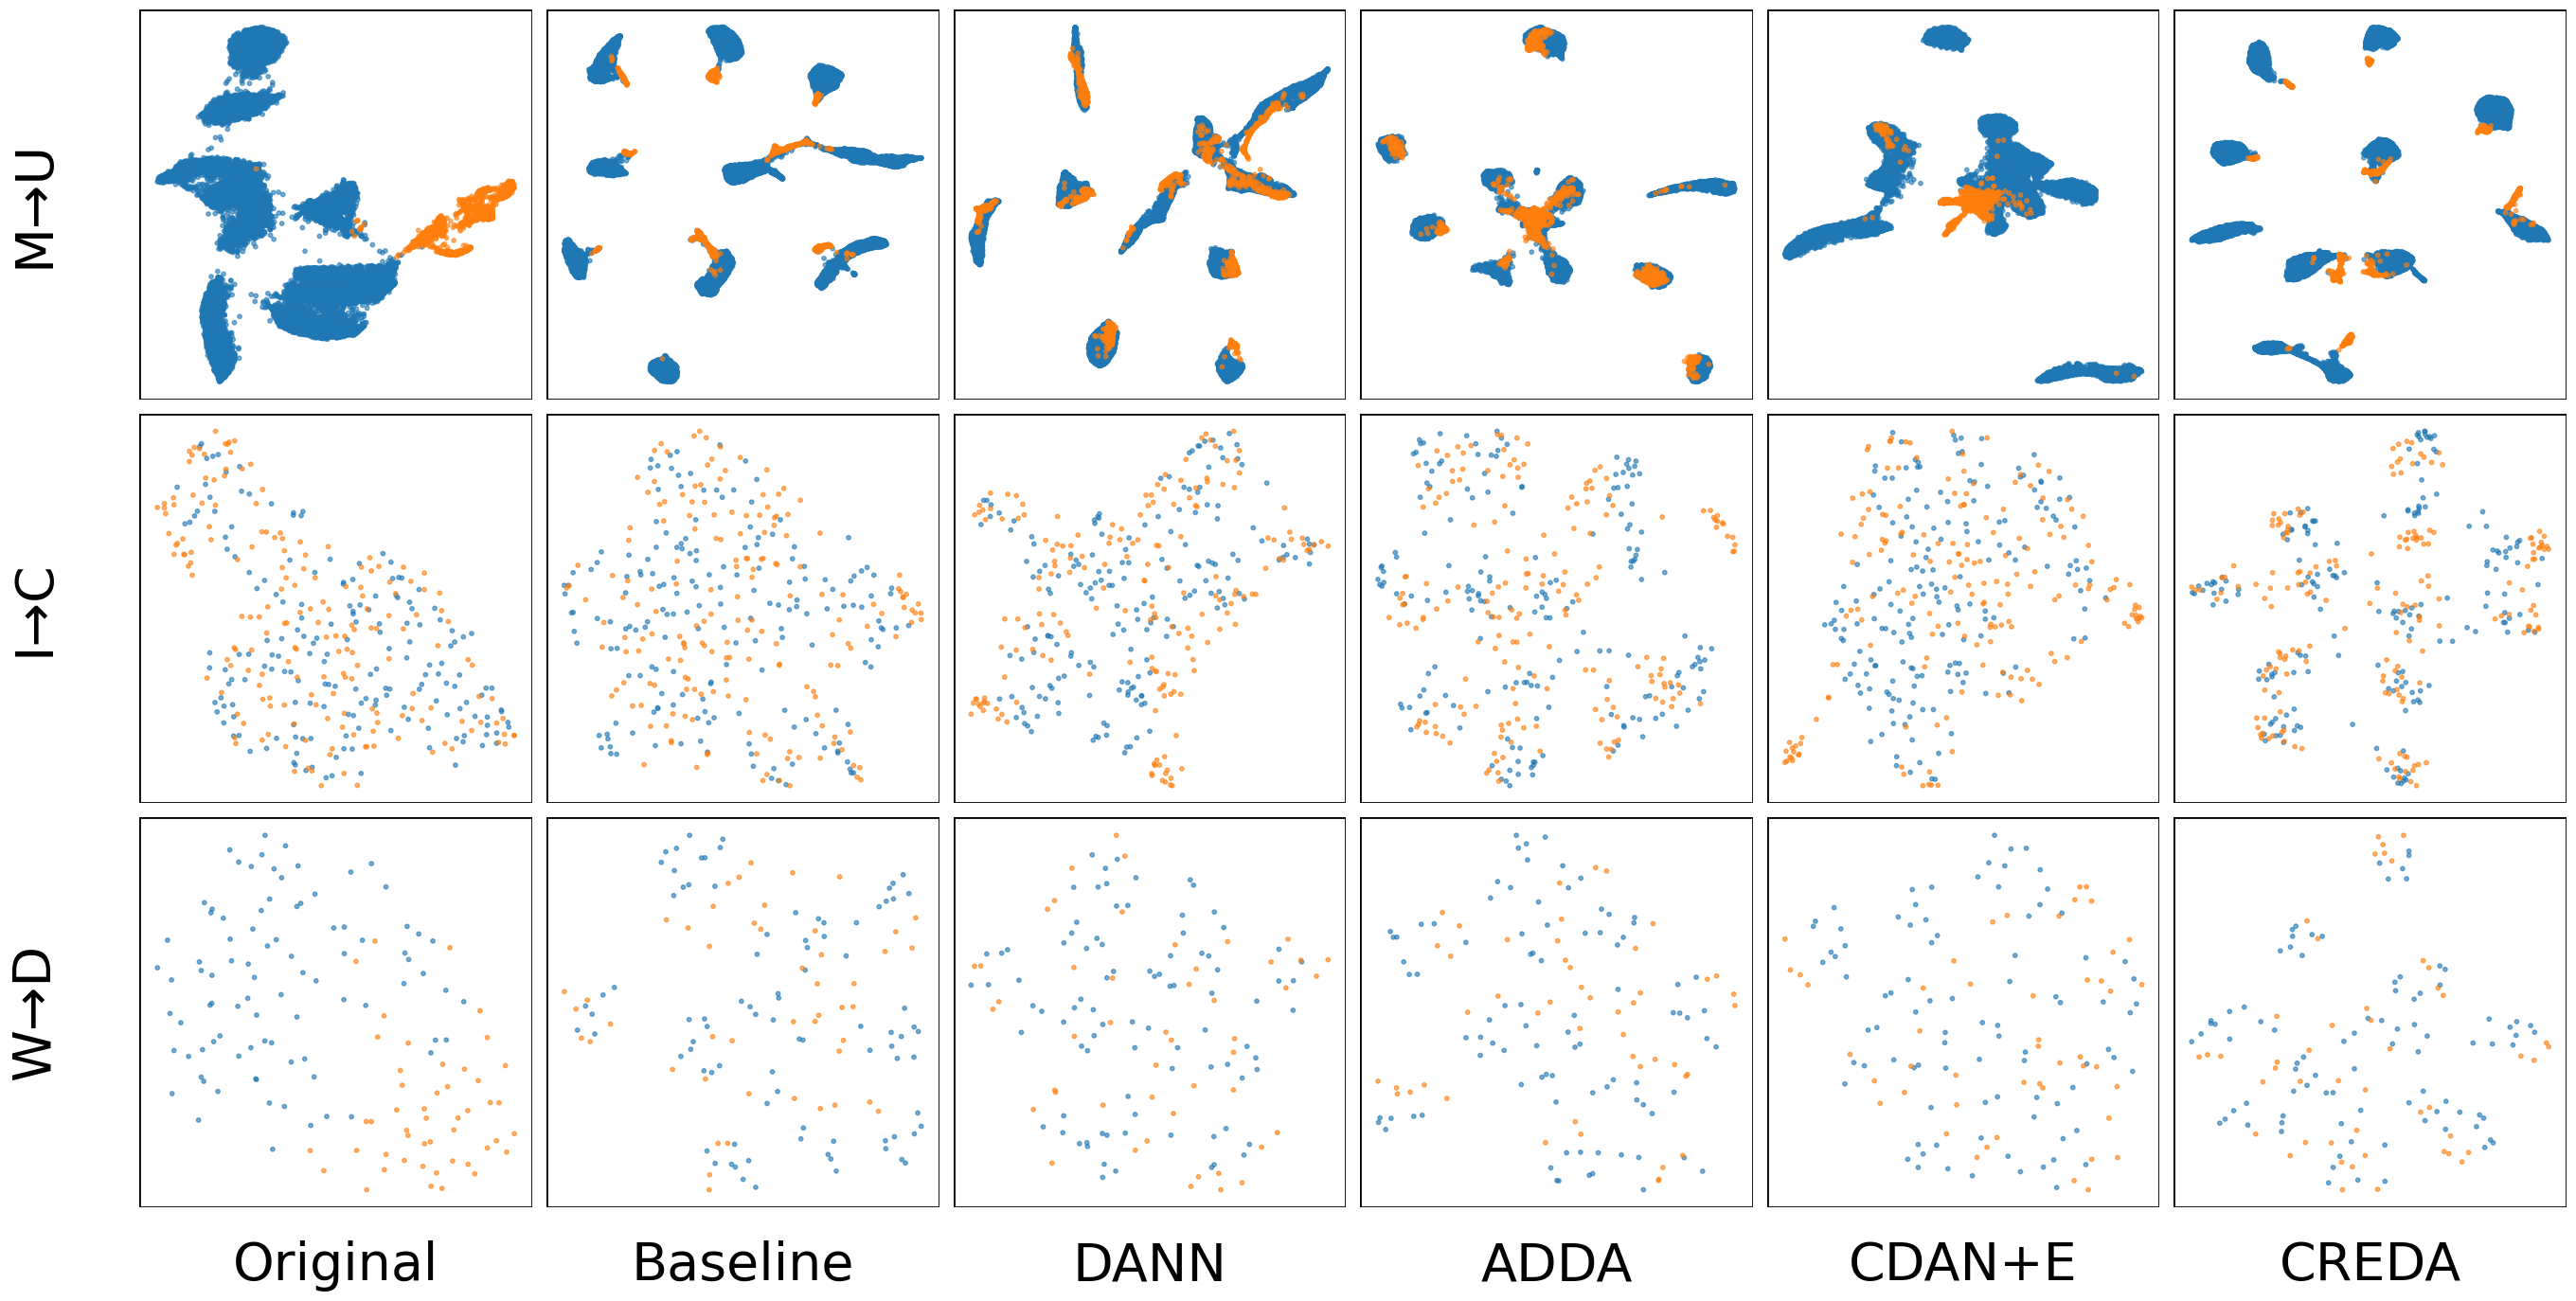

In [15]:
# Configuración
PLOT_BACKBONE = "resnet50"  # Must match a Results_Generator experiment profile.
model_names = ["baseline", "dann", "adda", "cdan", "creda"]
column_titles = ["Original", "Baseline", "DANN", "ADDA", "CDAN+E", "CREDA"]
dataset_names = ["MNIST-USPS-SVHN", "ImageCLEF", "Office-Caltech"]
row_labels = ["M→U", "I→C", "W→D"]
device = resolve_device()
cmap_binary = mpl.colors.ListedColormap(["#ff7f0e", "#1f77b4"])
creda_results = {}

# Función de resize PIL → np.array (28x28x3)


# Figura
fig, axes = plt.subplots(nrows=3, ncols=6, figsize=(30, 15))
fig.subplots_adjust(hspace=0, wspace=0)

# Proceso
for row_idx, dataset_key in enumerate(dataset_names):
    sets_dict = sets_all[dataset_key]
    src, tgt = combinations_dict[dataset_key]
    src_data = sets_dict[src]
    tgt_data = sets_dict[tgt]

    src_train, src_val, src_test = split_stratified(src_data, 0.15, 0.15)
    tgt_train, tgt_val, tgt_test = split_stratified(tgt_data, 0.15, 0.15)
    src_test = ConcatDataset([src_val, src_test])
    tgt_test = ConcatDataset([tgt_val, tgt_test])

    src_loader = DataLoader(src_test, batch_size=64, shuffle=False)
    tgt_loader = DataLoader(tgt_test, batch_size=64, shuffle=False)

    # Espacio original
    try:
        def flatten_loader(dataset):
            loader = DataLoader(dataset, batch_size=256, shuffle=False)
            X = []
            for x, _ in loader:
                X.append(x.view(x.size(0), -1).numpy())
            return np.vstack(X)

        src_features = flatten_loader(src_test)
        tgt_features = flatten_loader(tgt_test)
        features = np.concatenate([src_features, tgt_features], axis=0)
        is_source = np.array([1]*len(src_features) + [0]*len(tgt_features))

        Z = MinMaxScaler().fit_transform(fit_umap_2d(MinMaxScaler().fit_transform(features)))

        ax = axes[row_idx, 0]
        ax.set_facecolor("white")
        ax.scatter(Z[:, 0], Z[:, 1], c=is_source, cmap=cmap_binary, s=10, alpha=0.6)
        ax.axis("off")
        rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                 linewidth=2, edgecolor='black', facecolor='none')
        ax.add_patch(rect)

    except Exception as e:
        print(f"[Error espacio original] {src}->{tgt}: {e}")

    # Modelos
    targets = src_data.targets if hasattr(src_data, 'targets') else src_data.labels
    num_classes = len(set(targets.tolist() if hasattr(targets, 'tolist') else list(targets)))

    for col_idx, model_name in enumerate(model_names):
        ax = axes[row_idx, col_idx + 1]

        try:
            if model_name == "baseline":
                F, _ = load_model(model_name, src, tgt, models_root=ARTIFACT_PATHS["models"], backbone=PLOT_BACKBONE, num_classes=num_classes)
                F = F.to(device)
                features_src, _ = extract_features_baseline(F, src_loader, device)
                features_tgt, _ = extract_features_baseline(F, tgt_loader, device)
                labels_src, labels_tgt = None, None  # para consistencia
            else:
                model = load_model(model_name, src, tgt, models_root=ARTIFACT_PATHS["models"], backbone=PLOT_BACKBONE, num_classes=num_classes)
                model = model.to(device)
                features_src, labels_src = extract_features_adaptive(model, src_loader, domain="source", device=device)
                features_tgt, labels_tgt = extract_features_adaptive(model, tgt_loader, domain="target", device=device)

            features = np.concatenate([features_src, features_tgt], axis=0)
            is_source = np.array([1]*len(features_src) + [0]*len(features_tgt))

            X_scaled = MinMaxScaler().fit_transform(features)
            Z = MinMaxScaler().fit_transform(fit_umap_2d(X_scaled))

            ax.set_facecolor("white")
            ax.scatter(Z[:, 0], Z[:, 1], c=is_source, cmap=cmap_binary, s=10, alpha=0.6)
            ax.axis("off")
            rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                     linewidth=2, edgecolor='black', facecolor='none')
            ax.add_patch(rect)

            # Guardar representación solo para CREDA
            if model_name == "creda":
                def get_denormalizer(dataset_key):
                    if dataset_key == "MNIST-USPS-SVHN":
                        mean, std = [0.5]*3, [0.5]*3
                    else:
                        mean = [0.485, 0.456, 0.406]
                        std  = [0.229, 0.224, 0.225]
                    def denorm(t):
                        for ch, m, s in zip(t, mean, std):
                            ch.mul_(s).add_(m)
                        return t.clamp(0, 1)
                    return denorm

                denormalize = get_denormalizer(dataset_key)

                imgs_src = [resize_image_pil(to_pil_image(denormalize(x[0].clone().cpu()))) for x in src_test]
                imgs_tgt = [resize_image_pil(to_pil_image(denormalize(x[0].clone().cpu()))) for x in tgt_test]

                imgs = np.concatenate([imgs_src, imgs_tgt], axis=0)
                labels_all = np.concatenate([labels_src, labels_tgt])

                creda_results[dataset_key] = {
                    "Z": Z,
                    "is_source": is_source,
                    "labels_all": labels_all,
                    "imgs": imgs,
                    "num_classes": num_classes
                }

        except Exception as e:
            ax.set_title(f"{model_name.upper()} Failed", fontsize=10, color="red")
            ax.axis("off")
            print(f"[Error] {model_name.upper()} ({src}->{tgt}): {e}")

# Etiquetas de filas
for ax, row_label in zip(axes[:, 0], row_labels):
    ax.annotate(row_label, xy=(0, 0.5), xytext=(-60, 0),
                xycoords='axes fraction', textcoords='offset points',
                size=40, ha='right', va='center', rotation=90)

# Etiquetas de columnas (debajo)
for col_idx, model_name in enumerate(column_titles):
    ax = axes[-1, col_idx]
    ax.text(0.5, -0.15, model_name, transform=ax.transAxes,
            ha='center', va='center', fontsize=40)

plt.tight_layout(rect=[0.08, 0.03, 0.99, 0.95])
plt.savefig(PAPER_RESULTS_DIR / "umap_projection.pdf", format="pdf", bbox_inches="tight")
plt.show()

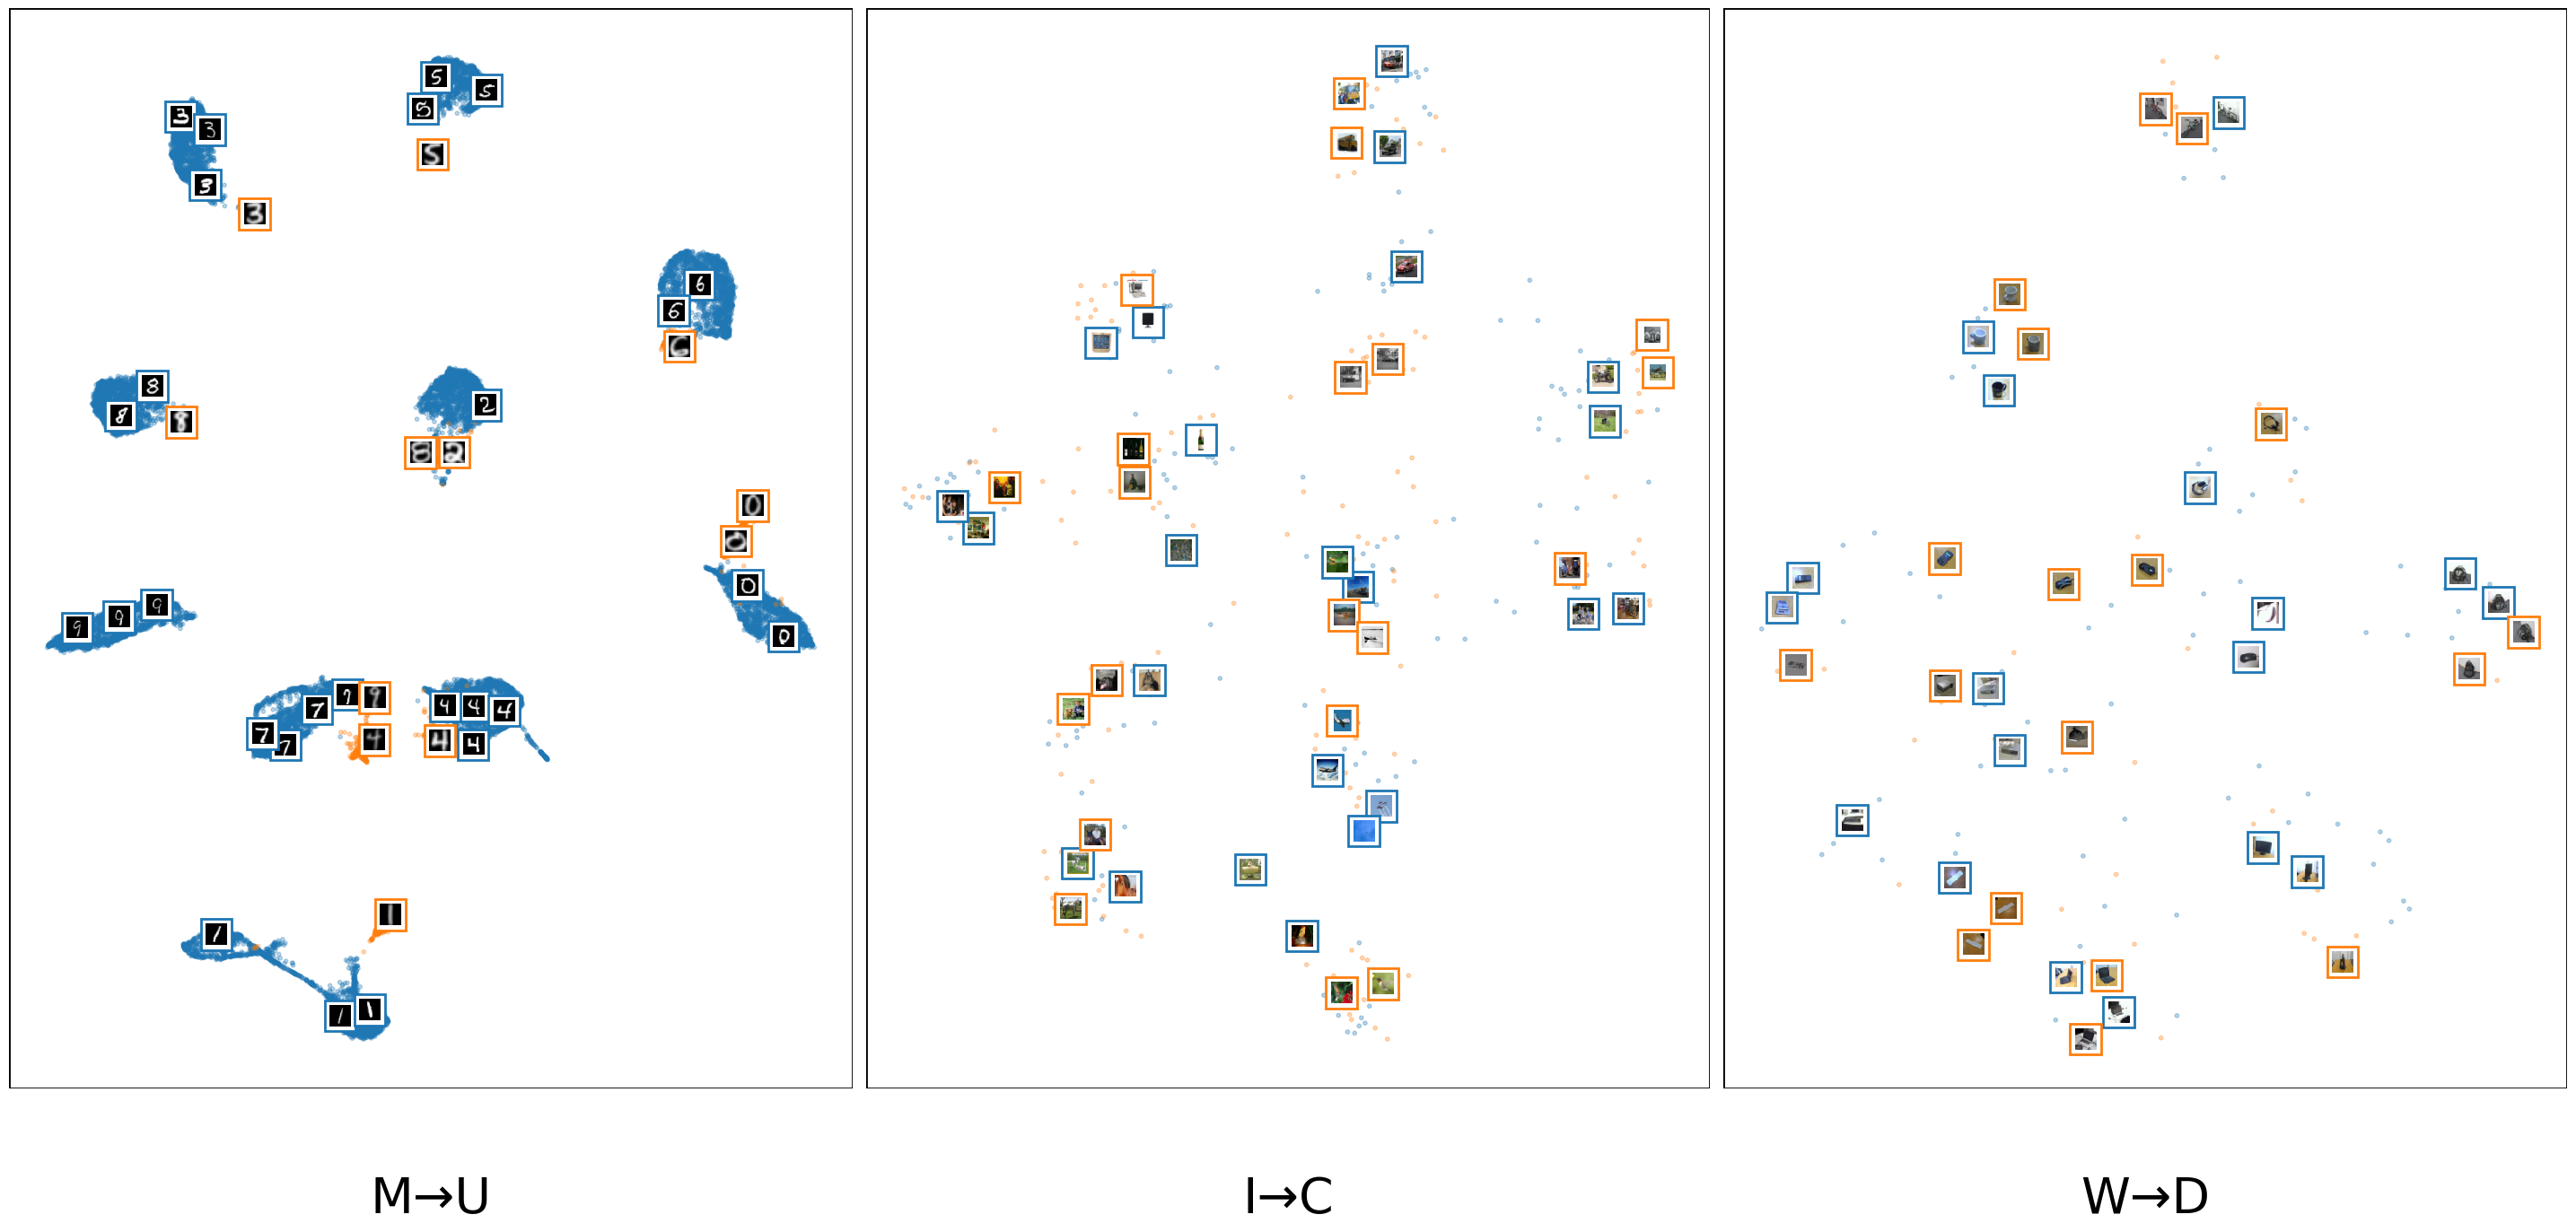

In [16]:
# Configuración
row_labels = ["M→U", "I→C", "W→D"]
cmap_binary = mpl.colors.ListedColormap(["#ff7f0e", "#1f77b4"])
n_img_per_domain = 60

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 15))
fig.subplots_adjust(wspace=0)

for i, dataset_key in enumerate(["MNIST-USPS-SVHN", "ImageCLEF", "Office-Caltech"]):
    ax = axes[i]

    try:
        data = creda_results[dataset_key]
        Z = data["Z"]
        is_source = data["is_source"]
        labels_all = data["labels_all"]
        imgs = data["imgs"]
        num_classes = data["num_classes"]

        ax.set_facecolor("white")
        ax.scatter(Z[:, 0], Z[:, 1], c=is_source, cmap=cmap_binary, s=10, alpha=0.3)
        ax.axis("off")

        idx_src = np.where(is_source == 1)[0]
        idx_tgt = np.where(is_source == 0)[0]

        if i in [1, 2]:
            idx_sampled = []
            for cls in range(num_classes):
                cls_src = idx_src[labels_all[idx_src] == cls]
                cls_tgt = idx_tgt[labels_all[idx_tgt] == cls]
                if len(cls_src) >= 2:
                    idx_sampled.extend(np.random.choice(cls_src, 2, replace=False))
                elif len(cls_src) > 0:
                    idx_sampled.extend(np.random.choice(cls_src, 1, replace=False))
                if len(cls_tgt) >= 2:
                    idx_sampled.extend(np.random.choice(cls_tgt, 2, replace=False))
                elif len(cls_tgt) > 0:
                    idx_sampled.extend(np.random.choice(cls_tgt, 1, replace=False))
        else:
            idx_sampled = np.concatenate([
                np.random.choice(idx_src, min(n_img_per_domain, len(idx_src)), replace=False),
                np.random.choice(idx_tgt, min(n_img_per_domain, len(idx_tgt)), replace=False)
            ])

        image_positions = np.array([[10., 10.]])
        for j in idx_sampled:
            pos = Z[j]
            img_array = imgs[j]

            if np.min(np.sum((pos - image_positions)**2, axis=1)) > 0.001:
                image_positions = np.vstack([image_positions, pos])
                ab = AnnotationBbox(
                    OffsetImage(img_array, zoom=0.6, interpolation='nearest'),
                    pos,
                    bboxprops=dict(
                        edgecolor=cmap_binary(is_source[j]),
                        linewidth=2,
                        linestyle='solid'
                    ),
                    frameon=True
                )
                ax.add_artist(ab)

        ax.add_patch(patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                       linewidth=2, edgecolor='black', facecolor='none'))
        ax.text(0.5, -0.08, row_labels[i],
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=40)


        if i == 0:
            handles = [
                mpl.patches.Patch(color=cmap_binary(1), label="Source"),
                mpl.patches.Patch(color=cmap_binary(0), label="Target")
            ]


    except Exception as e:
        ax.set_title(f"CREDA Failed", fontsize=20, color="red")
        ax.axis("off")
        print(f"[Error] {dataset_key}: {e}")

plt.tight_layout(rect=[0.03, 0.03, 0.99, 0.95])
plt.savefig(PAPER_RESULTS_DIR / "umap_creda_images.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [17]:

device         = resolve_device()
dataset_names  = ["ImageCLEF", "Office-Caltech"]
n_classes      = 3
batch_size     = 64
index_to_pick  = 0  # <-- eliges qué imagen quieres por clase: 0 = primera, 1 = segunda, etc.

fig, axes = plt.subplots(nrows=len(dataset_names), ncols=n_classes, figsize=(30, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for row_idx, dataset_key in enumerate(dataset_names):
    sets_dict           = sets_all[dataset_key]
    src_key, tgt_key    = combinations_dict[dataset_key]
    src_data, tgt_data  = sets_dict[src_key], sets_dict[tgt_key]

    src_train, src_val, src_test = split_stratified(src_data, 0.15, 0.15)
    tgt_train, tgt_val, tgt_test = split_stratified(tgt_data, 0.15, 0.15)
    src_test = ConcatDataset([src_val, src_test])
    tgt_test = ConcatDataset([tgt_val, tgt_test])

    src_loader = DataLoader(src_test, batch_size=batch_size, shuffle=False)
    tgt_loader = DataLoader(tgt_test, batch_size=batch_size, shuffle=False)

    targets = src_data.targets if hasattr(src_data, 'targets') else src_data.labels
    num_classes = len(set(targets.tolist() if hasattr(targets, 'tolist') else list(targets)))

    model = load_model("creda", src_key, tgt_key,
                       models_root=ARTIFACT_PATHS["models"],
                       backbone=PLOT_BACKBONE,
                       num_classes=num_classes).eval().to(device)

    cam_extractor = GradCAMpp(model, target_layer=get_last_conv_layer(model))
    denormalize   = get_denormalizer(dataset_key)

    for class_idx in range(n_classes):
        ax = axes[row_idx, class_idx]

        img_src = get_nth_image_for_class(src_loader, class_idx, index=index_to_pick, device=device)
        img_tgt = get_nth_image_for_class(tgt_loader, class_idx, index=index_to_pick, device=device)

        if img_src is None or img_tgt is None:
            ax.set_title(f"No data", color='red')
            ax.axis("off")
            continue

        cam_src = cam_extractor(class_idx, model(img_src.unsqueeze(0).to(device)))[0].cpu()
        cam_tgt = cam_extractor(class_idx, model(img_tgt.unsqueeze(0).to(device)))[0].cpu()
        cam_src, cam_tgt = norm_cam(cam_src), norm_cam(cam_tgt)

        img_src_denorm = denormalize(img_src.clone())
        img_tgt_denorm = denormalize(img_tgt.clone())

        overlay_src = overlay_mask(to_pil_image(img_src_denorm),
                                   to_pil_image(cam_src, mode='F'),
                                   alpha=0.7)
        overlay_tgt = overlay_mask(to_pil_image(img_tgt_denorm),
                                   to_pil_image(cam_tgt, mode='F'),
                                   alpha=0.7)

        ax.imshow(np.hstack([np.array(overlay_src), np.array(overlay_tgt)]))
        ax.axis("off")

        # Etiqueta de clase debajo solo en la última fila
        if row_idx == len(dataset_names) - 1:
            ax.text(0.5, -0.15, f"Clase {class_idx}",
                    transform=ax.transAxes,
                    ha='center', va='center',
                    fontsize=40)

# Etiquetas del dataset a la izquierda
row_labels = ["ImageCLEF-DA", "Office-31"]
for row_idx, dataset_key in enumerate(row_labels):
    ax = axes[row_idx, 0]
    ax.annotate(dataset_key,
                xy=(-0.15, 0.5), xycoords='axes fraction',
                textcoords='offset points',
                ha='right', va='center',
                fontsize=40, rotation=90)

plt.tight_layout(rect=[0.03, 0.03, 0.99, 0.95])
plt.savefig(PAPER_RESULTS_DIR / "Cams.pdf", format="pdf", bbox_inches="tight")
plt.show()

Output hidden; open in https://colab.research.google.com to view.